In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [2]:
ele_price = pd.read_excel('/Users/geng44/Desktop/project/Average_retail_price_of_electricity.xlsx')

ff_price = pd.read_excel('/Users/geng44/Desktop/project/Average_cost_of_fossil_fuels_for_electricity_generation.xlsx')

ff_receipt = pd.read_excel('/Users/geng44/Desktop/project/Receipts_of_fossil_fuels_by_electricity_plants_for_all_sectors.xlsx')

net_gene = pd.read_excel('/Users/geng44/Desktop/project/Net_generation.xlsx')

In [3]:
ele_price_T = ele_price.T
ele_price_T.columns = ele_price_T.iloc[0]
ele_price_T = ele_price_T[1:]

In [4]:
ff_price_T = ff_price.T
ff_price_T.columns = ff_price_T.iloc[0]
ff_price_T = ff_price_T[1:]

In [5]:
ff_receipt_T = ff_receipt.T
ff_receipt_T.columns = ff_receipt_T.iloc[0]
ff_receipt_T = ff_receipt_T[1:]

In [6]:
net_gene_T = net_gene.T
net_gene_T.columns = net_gene_T.iloc[0]
net_gene_T = net_gene_T[1:]
net_gene_T.fillna(0, inplace=True)

/var/folders/ty/9rmz2lcd2p35hd3wb4_5v6_m0000gs/T/ipykernel_82716/1080020301.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  net_gene_T.fillna(0, inplace=True)


In [7]:
ff_receipt_T

description,coal,bituminous coal,subbituminous coal,lignite coal,petroleum liquids,petroleum coke,natural gas
2008-01-01 00:00:00,87608,37885,42373,5985,4965,628,639424
2008-02-01 00:00:00,84048,36201,41218,5406,3852,422,538625
2008-03-01 00:00:00,87826,39224,42789,4799,3721,630,563326
2008-04-01 00:00:00,86916,38415,42412,4898,6041,612,569441
2008-05-01 00:00:00,88716,40135,41773,5622,4102,516,575650
...,...,...,...,...,...,...,...
2025-08-01 00:00:00,35625,11011,20918,3192,1527,127,1288923
2025-09-01 00:00:00,33684,11084,19635,2601,1039,84,1125996
2025-10-01 00:00:00,34535,11630,19754,2942,1154,133,971380
2025-11-01 00:00:00,33085,10884,18797,3031,1365,86,896400


In [8]:
ff_price_T

description,coal,bituminous coal,subbituminous coal,lignite coal,petroleum liquids,petroleum coke,natural gas
2008-01-01 00:00:00,1.88,2.2,1.55,1.33,14.61,1.62,8.19
2008-02-01 00:00:00,1.89,2.22,1.55,1.37,15.03,1.82,8.58
2008-03-01 00:00:00,1.93,2.25,1.57,1.38,14.67,1.82,9.25
2008-04-01 00:00:00,1.97,2.33,1.57,1.42,14.65,1.79,9.89
2008-05-01 00:00:00,2.04,2.41,1.63,1.37,17.13,1.96,10.73
...,...,...,...,...,...,...,...
2025-08-01 00:00:00,2.41,3.01,2.06,1.76,16.82,2.9,3.17
2025-09-01 00:00:00,2.41,2.97,2.03,1.94,16.25,2.73,3.04
2025-10-01 00:00:00,2.39,2.95,1.99,2.0,16.4,2.66,3.08
2025-11-01 00:00:00,2.39,2.92,2.03,2.08,16.46,2.51,3.89


In [9]:
ele_price_T

description,all sectors,residential,commercial,industrial,transportation,other
2001-01-01 00:00:00,6.75,7.73,7.25,4.73,NaN,6.48
2001-02-01 00:00:00,6.87,8.04,7.51,4.8,NaN,6.94
2001-03-01 00:00:00,7.01,8.32,7.7,4.86,NaN,7.05
2001-04-01 00:00:00,7.02,8.46,7.73,4.87,NaN,7.04
2001-05-01 00:00:00,7.17,8.83,7.77,5.0,NaN,7.14
...,...,...,...,...,...,...
2025-08-01 00:00:00,14.22,17.61,13.93,9.08,14.86,NaN
2025-09-01 00:00:00,14.21,18.08,13.99,9.02,15.25,NaN
2025-10-01 00:00:00,13.66,17.97,13.49,8.65,13.56,NaN
2025-11-01 00:00:00,13.43,17.78,13.19,8.44,13.64,NaN


In [10]:
net_gene_T

description,all fuels (utility-scale),coal,petroleum liquids,petroleum coke,natural gas,other gases,nuclear,conventional hydroelectric,other renewables,wind,all utility-scale solar,geothermal,biomass,wood and wood-derived fuels,other biomass,hydro-electric pumped storage,other,all solar,small-scale solar photovoltaic,all utility-scale solar
2008-01-01 00:00:00,362998.0,182876.0,3131.0,1366.0,72600.0,1063.0,70735.0,20779.0,0,4273.0,16.0,1209.0,4744.0,3338.0,1407.0,-746.0,951.0,0.0,0.0,16.0
2008-02-01 00:00:00,325106.0,166666.0,2438.0,1231.0,60042.0,972.0,65130.0,18789.0,0,3852.0,36.0,1087.0,4374.0,3010.0,1364.0,-451.0,939.0,0.0,0.0,36.0
2008-03-01 00:00:00,324630.0,160743.0,2112.0,1039.0,62171.0,1049.0,64716.0,21669.0,0,4782.0,75.0,1251.0,4596.0,3123.0,1472.0,-553.0,980.0,0.0,0.0,75.0
2008-04-01 00:00:00,305865.0,146983.0,2274.0,1126.0,63046.0,1021.0,57333.0,22234.0,0,5225.0,94.0,1218.0,4433.0,2930.0,1504.0,-132.0,1008.0,0.0,0.0,94.0
2008-05-01 00:00:00,325245.0,154916.0,2343.0,1055.0,62270.0,1044.0,64826.0,27221.0,0,5340.0,99.0,1259.0,4402.0,2927.0,1475.0,-587.0,1057.0,0.0,0.0,99.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01 00:00:00,420242.0,69728.0,1019.0,501.0,192894.0,864.0,70705.0,20098.0,0,27307.0,31809.0,1349.0,4037.0,2833.0,1204.0,-568.0,499.0,41128.0,9319.0,31809.0
2025-09-01 00:00:00,368145.0,58302.0,907.0,390.0,167876.0,963.0,65458.0,15285.0,0,25673.0,28149.0,1284.0,3849.0,2713.0,1136.0,-457.0,467.0,36325.0,8176.0,28149.0
2025-10-01 00:00:00,345253.0,54019.0,942.0,437.0,143985.0,1086.0,59222.0,16545.0,0,39534.0,24605.0,1267.0,3628.0,2467.0,1161.0,-513.0,497.0,32195.0,7589.0,24605.0
2025-11-01 00:00:00,334986.0,54490.0,981.0,334.0,131565.0,867.0,63809.0,18415.0,0,40957.0,18592.0,1263.0,3769.0,2581.0,1188.0,-610.0,554.0,24580.0,5987.0,18592.0


In [11]:
# natural gas generation share in electricity production
net_gene_T['ng_share'] = net_gene_T['natural gas']/net_gene_T['all fuels (utility-scale)']

In [12]:
# electricity price from cents per kwh to dollar per kwh
ele_price_T = ele_price_T/ 100

In [13]:
# fuel price from dollar per million Btu to dollar per kwh
ff_price_T = ff_price_T / 293.07 / 0.9

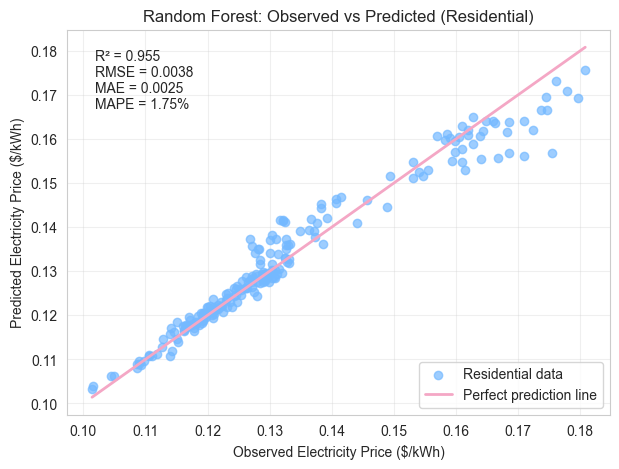

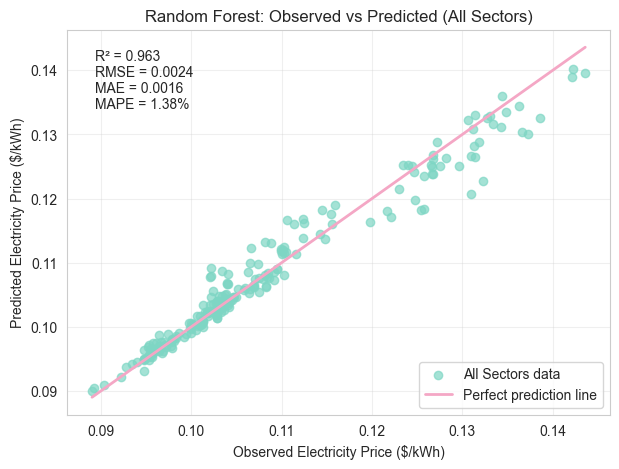

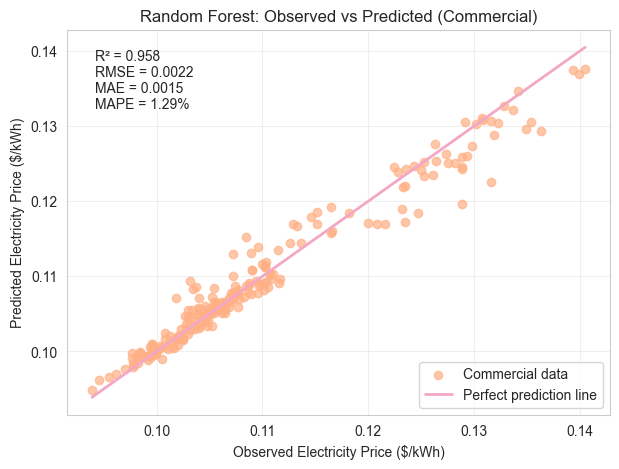

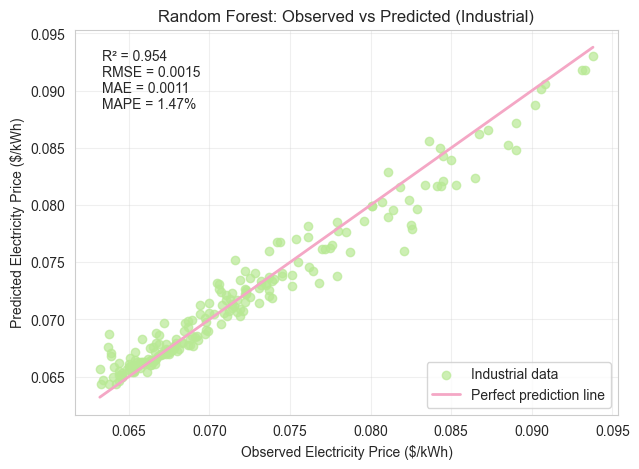

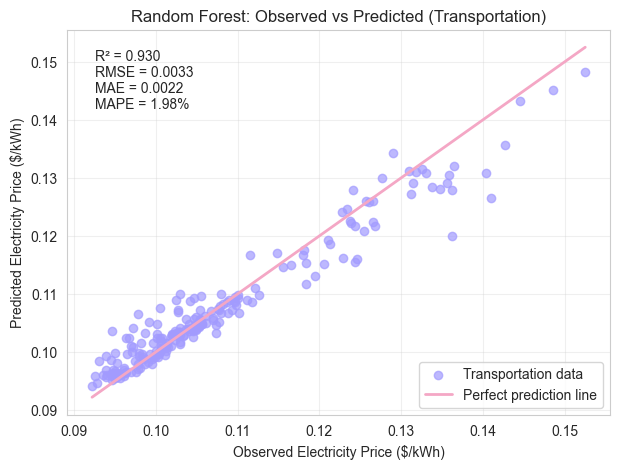

Model performance:


,Sector,RMSE,MAE,MAPE (%),R2
0,Residential,0.003822,0.002470,1.754410,0.955311
1,All Sectors,0.002383,0.001563,1.378174,0.962765
2,Commercial,0.002188,0.001460,1.286118,0.958104
3,Industrial,0.001510,0.001074,1.466284,0.953648
4,Transportation,0.003321,0.002197,1.984010,0.930268


Feature importance:


,Sector,Feature,Importance
0,Residential,gas_price,0.141058
1,Residential,ng_share,0.790572
2,Residential,gas_receipt,0.068370
3,All Sectors,gas_price,0.138640
4,All Sectors,ng_share,0.745060
5,All Sectors,gas_receipt,0.116300
6,Commercial,gas_price,0.166107
7,Commercial,ng_share,0.716760
8,Commercial,gas_receipt,0.117133
9,Industrial,gas_price,0.201510


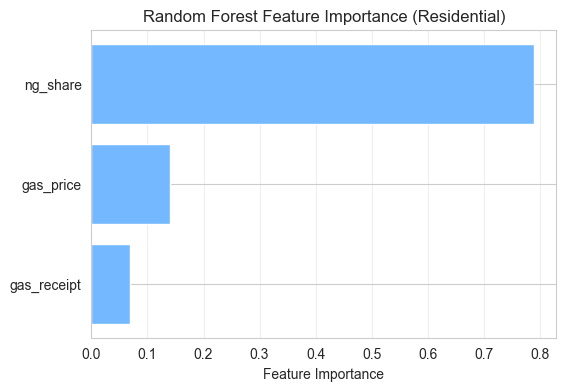

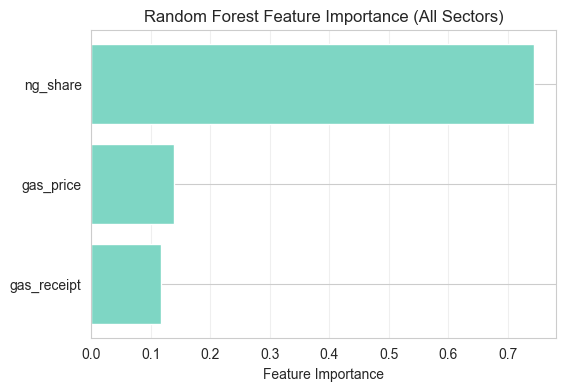

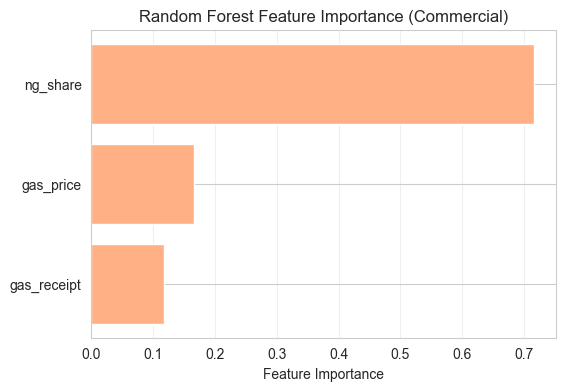

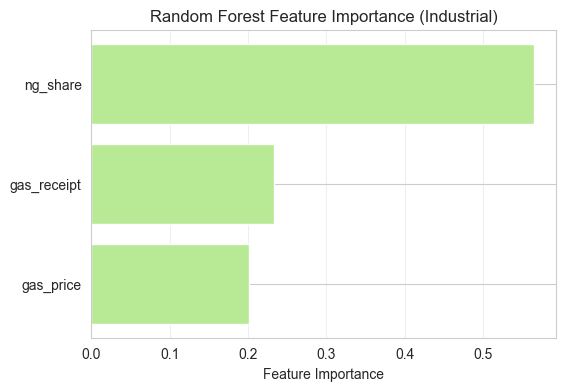

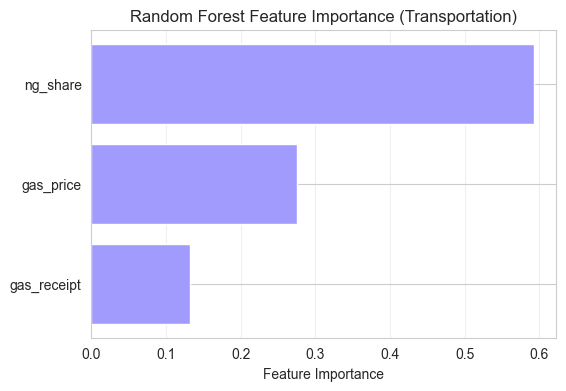

In [14]:
sector_info = {
    'residential': {'color': '#74B9FF', 'label': 'Residential'},
    'all sectors': {'color': '#7ED6C4', 'label': 'All Sectors'},
    'commercial': {'color': '#FFB085', 'label': 'Commercial'},
    'industrial': {'color': '#B8E994', 'label': 'Industrial'},
    'transportation': {'color': '#A29BFE', 'label': 'Transportation'}
}

results = []
importance_results = []

for sector, info in sector_info.items():

    df = pd.DataFrame({
        'gas_price': ff_price_T['natural gas'],
        'ng_share': net_gene_T['ng_share'],
        'gas_receipt': ff_receipt_T['natural gas'],
        'ele_price': ele_price_T[sector]
    }).dropna()

    X = df[['gas_price', 'ng_share', 'gas_receipt']]
    y = df['ele_price']

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X, y)
    y_pred = model.predict(X)

    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    mape = np.mean(np.abs((y - y_pred) / (y + 1e-6))) * 100
    r2 = r2_score(y, y_pred)

    results.append({
        'Sector': info['label'],
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'R2': r2
    })

    importance = pd.Series(model.feature_importances_, index=X.columns)

    for feature, value in importance.items():
        importance_results.append({
            'Sector': info['label'],
            'Feature': feature,
            'Importance': value
        })

    # plot observed vs predicted
    plt.figure(figsize=(7, 5))

    plt.scatter(
        y,
        y_pred,
        color=info['color'],
        alpha=0.7,
        label=f'{info["label"]} data'
    )

    min_val = min(y.min(), y_pred.min())
    max_val = max(y.max(), y_pred.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        color='#F4A7C5',
        linewidth=2,
        label='Perfect prediction line'
    )

    plt.xlabel('Observed Electricity Price ($/kWh)')
    plt.ylabel('Predicted Electricity Price ($/kWh)')
    plt.title(f'Random Forest: Observed vs Predicted ({info["label"]})')

    plt.text(
        0.05, 0.95,
        f'R² = {r2:.3f}\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}\nMAPE = {mape:.2f}%',
        transform=plt.gca().transAxes,
        verticalalignment='top'
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

results_df = pd.DataFrame(results)
importance_df = pd.DataFrame(importance_results)

print("Model performance:")
display(results_df)

print("Feature importance:")
display(importance_df)

for sector, info in sector_info.items():

    temp = importance_df[importance_df['Sector'] == info['label']]
    temp = temp.sort_values('Importance', ascending=True)

    plt.figure(figsize=(6, 4))

    plt.barh(
        temp['Feature'],
        temp['Importance'],
        color=info['color']
    )

    plt.xlabel('Feature Importance')
    plt.title(f'Random Forest Feature Importance ({info["label"]})')
    plt.grid(axis='x', alpha=0.3)
    plt.show()

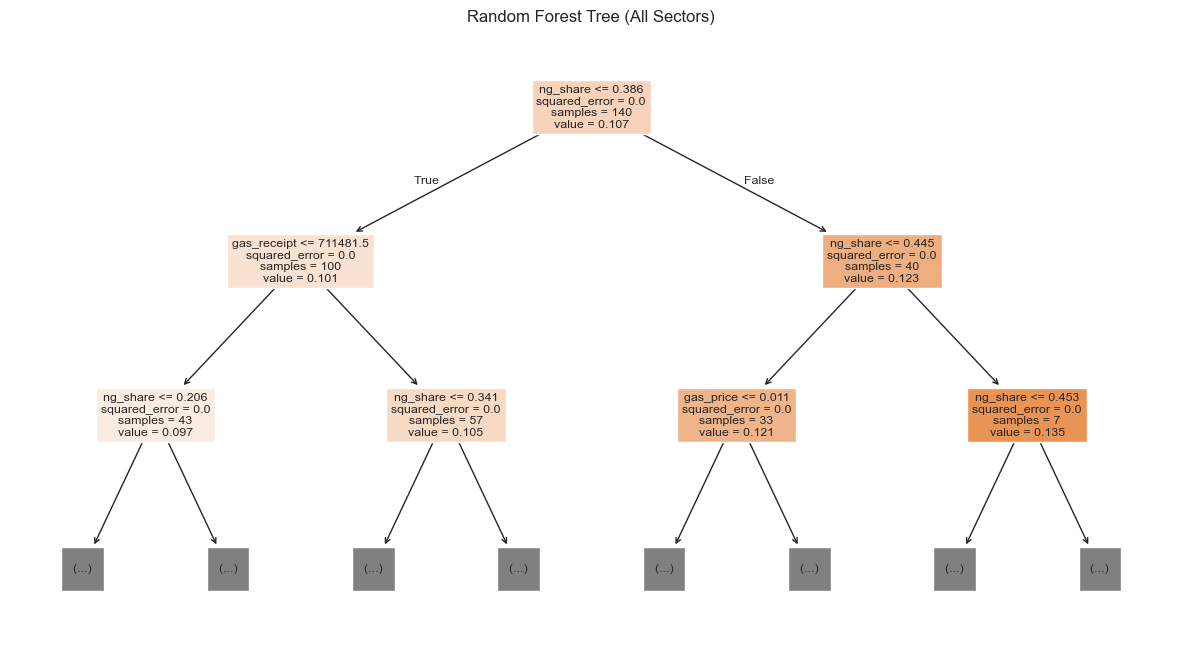

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import pandas as pd

# all sectors data build
df = pd.DataFrame({
    'gas_price': ff_price_T['natural gas'],
    'ng_share': net_gene_T['ng_share'],
    'gas_receipt': ff_receipt_T['natural gas'],
    'ele_price': ele_price_T['all sectors']
}).dropna()

X = df[['gas_price', 'ng_share', 'gas_receipt']]
y = df['ele_price']

# Random Forest
model_all = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model_all.fit(X, y)

# one tree
tree = model_all.estimators_[0]

# plot
plt.figure(figsize=(15, 8))

plot_tree(
    tree,
    feature_names=X.columns,
    filled=True,
    max_depth=2
)

plt.title("Random Forest Tree (All Sectors)")
plt.show()

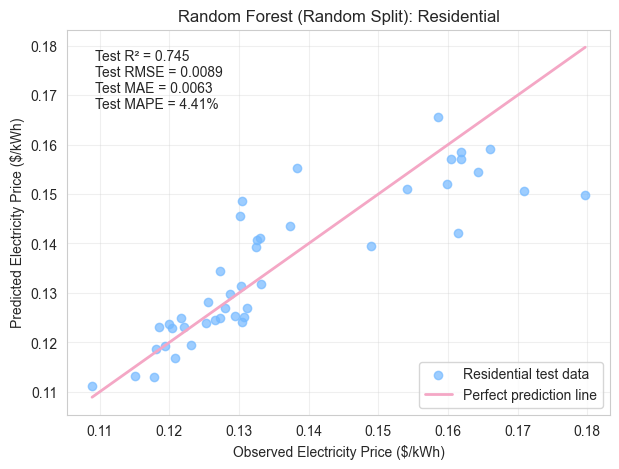

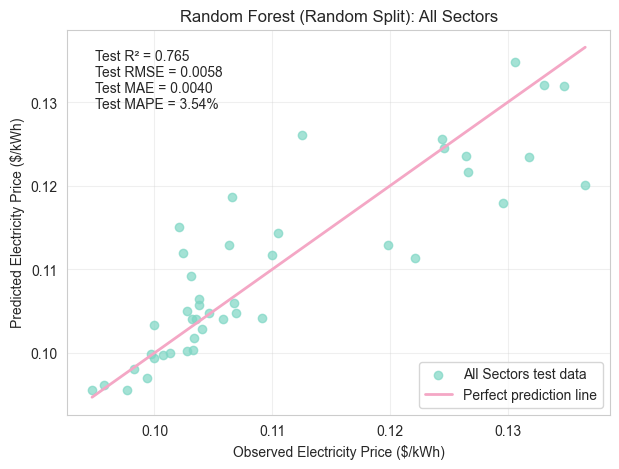

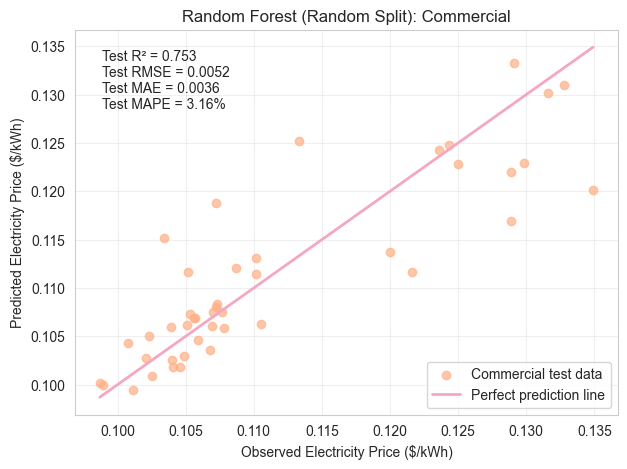

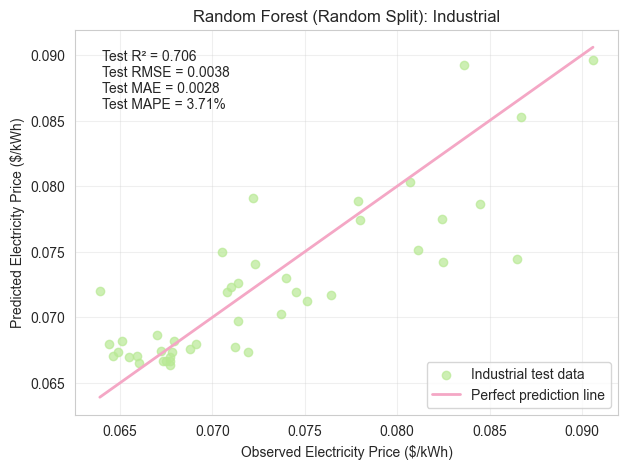

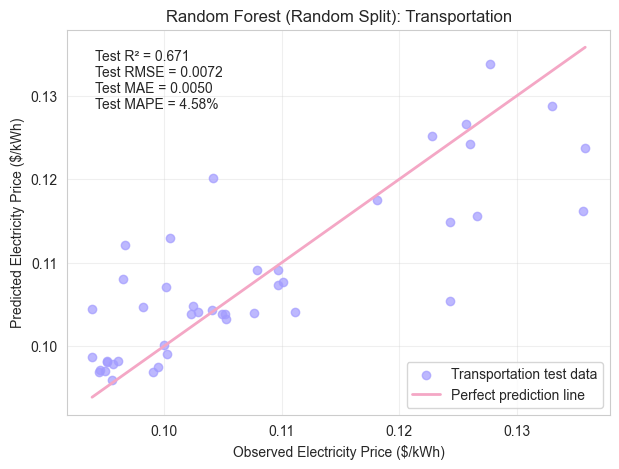

Model performance:


,Sector,Train R2,Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MAPE (%),Test MAPE (%)
0,Residential,0.909876,0.745488,0.005433,0.008854,0.003852,0.006310,2.761125,4.405847
1,All Sectors,0.923197,0.764904,0.003433,0.005810,0.002463,0.004022,2.199060,3.544107
2,Commercial,0.909391,0.752627,0.003220,0.005210,0.002375,0.003624,2.115944,3.163814
3,Industrial,0.876902,0.706068,0.002458,0.003773,0.001894,0.002756,2.619639,3.705242
4,Transportation,0.840721,0.670814,0.005018,0.007229,0.003647,0.005014,3.338041,4.577658


Feature importance:


,Sector,Feature,Importance
0,Residential,gas_price,0.123009
1,Residential,ng_share,0.816353
2,Residential,gas_receipt,0.060638
3,All Sectors,gas_price,0.128011
4,All Sectors,ng_share,0.758986
5,All Sectors,gas_receipt,0.113003
6,Commercial,gas_price,0.149932
7,Commercial,ng_share,0.731471
8,Commercial,gas_receipt,0.118597
9,Industrial,gas_price,0.184888


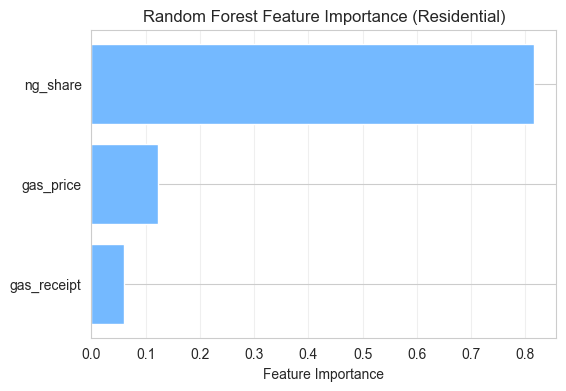

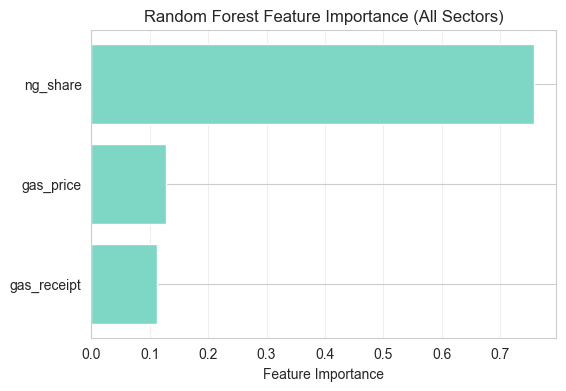

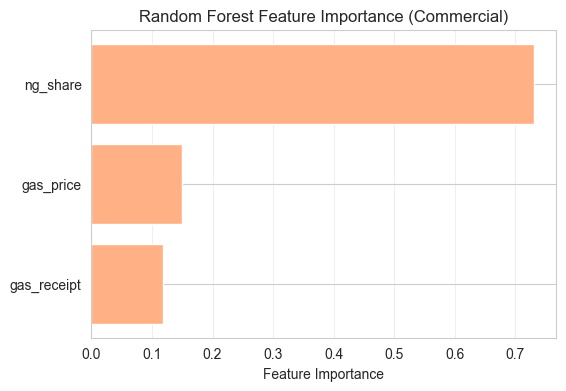

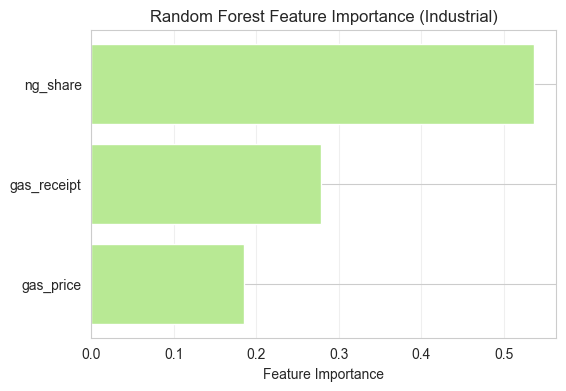

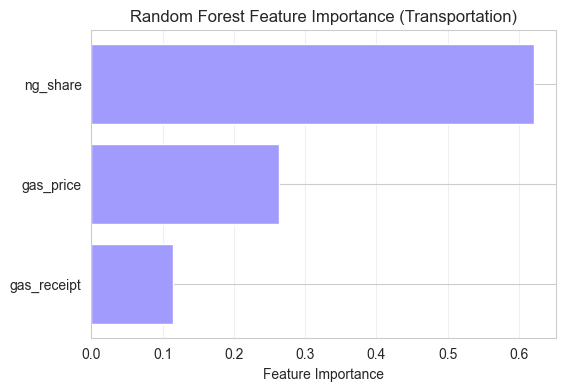

In [16]:
sector_info = {
    'residential': {'color': '#74B9FF', 'label': 'Residential'},
    'all sectors': {'color': '#7ED6C4', 'label': 'All Sectors'},
    'commercial': {'color': '#FFB085', 'label': 'Commercial'},
    'industrial': {'color': '#B8E994', 'label': 'Industrial'},
    'transportation': {'color': '#A29BFE', 'label': 'Transportation'}
}

results = []
importance_results = []

for sector, info in sector_info.items():

    df = pd.DataFrame({
        'gas_price': ff_price_T['natural gas'],
        'ng_share': net_gene_T['ng_share'],
        'gas_receipt': ff_receipt_T['natural gas'],
        'ele_price': ele_price_T[sector]
    }).dropna()

    X = df[['gas_price', 'ng_share', 'gas_receipt']]
    y = df['ele_price']

    # train and test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_mape = np.mean(np.abs((y_train - y_train_pred) / (y_train + 1e-6))) * 100
    test_mape = np.mean(np.abs((y_test - y_test_pred) / (y_test + 1e-6))) * 100

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results.append({
        'Sector': info['label'],
        'Train R2': train_r2,
        'Test R2': test_r2,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Train MAPE (%)': train_mape,
        'Test MAPE (%)': test_mape
    })

    # feature importance
    importance = pd.Series(model.feature_importances_, index=X.columns)

    for feature, value in importance.items():
        importance_results.append({
            'Sector': info['label'],
            'Feature': feature,
            'Importance': value
        })

    # test scatter
    plt.figure(figsize=(7, 5))

    plt.scatter(
        y_test,
        y_test_pred,
        color=info['color'],
        alpha=0.7,
        label=f'{info["label"]} test data'
    )

    min_val = min(y_test.min(), y_test_pred.min())
    max_val = max(y_test.max(), y_test_pred.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        color='#F4A7C5',
        linewidth=2,
        label='Perfect prediction line'
    )

    plt.xlabel('Observed Electricity Price ($/kWh)')
    plt.ylabel('Predicted Electricity Price ($/kWh)')
    plt.title(f'Random Forest (Random Split): {info["label"]}')

    plt.text(
        0.05, 0.95,
        f'Test R² = {test_r2:.3f}\nTest RMSE = {test_rmse:.4f}\nTest MAE = {test_mae:.4f}\nTest MAPE = {test_mape:.2f}%',
        transform=plt.gca().transAxes,
        verticalalignment='top'
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# summary tables
results_df = pd.DataFrame(results)
importance_df = pd.DataFrame(importance_results)

print("Model performance:")
display(results_df)

print("Feature importance:")
display(importance_df)

# feature importance plot
for sector, info in sector_info.items():

    temp = importance_df[importance_df['Sector'] == info['label']]
    temp = temp.sort_values('Importance', ascending=True)

    plt.figure(figsize=(6, 4))

    plt.barh(
        temp['Feature'],
        temp['Importance'],
        color=info['color']
    )

    plt.xlabel('Feature Importance')
    plt.title(f'Random Forest Feature Importance ({info["label"]})')
    plt.grid(axis='x', alpha=0.3)
    plt.show()

In [17]:
results_df.to_csv('random_forest_results.csv')
importance_df.to_csv('random_forest_importance.csv', index=False)

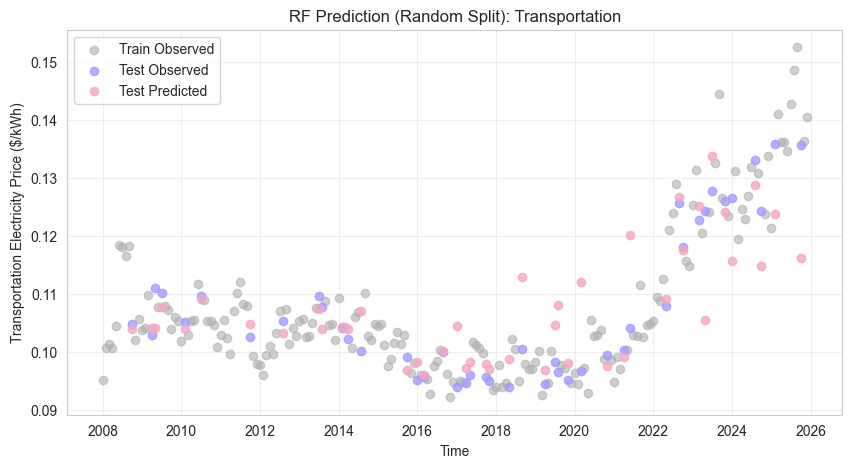

In [18]:
# time sequency
df.index = pd.to_datetime(df.index, errors='coerce')
df = df.sort_index()

X = df[['gas_price', 'ng_share', 'gas_receipt']]
y = df['ele_price']

# split index
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# time sequency plot
plt.figure(figsize=(10,5))

# train
plt.scatter(
    y_train.index,
    y_train,
    color='#B0B0B0',
    label='Train Observed',
    alpha=0.6
)

# test
plt.scatter(
    y_test.index,
    y_test,
    color=info['color'],
    label='Test Observed',
    alpha=0.8
)

# test
plt.scatter(
    y_test.index,
    y_test_pred,
    color='#F4A7C5',
    label='Test Predicted',
    alpha=0.8
)

plt.xlabel('Time')
plt.ylabel(f'{info["label"]} Electricity Price ($/kWh)')
plt.title(f'RF Prediction (Random Split): {info["label"]}')

plt.legend()
plt.grid(alpha=0.3)
plt.show()

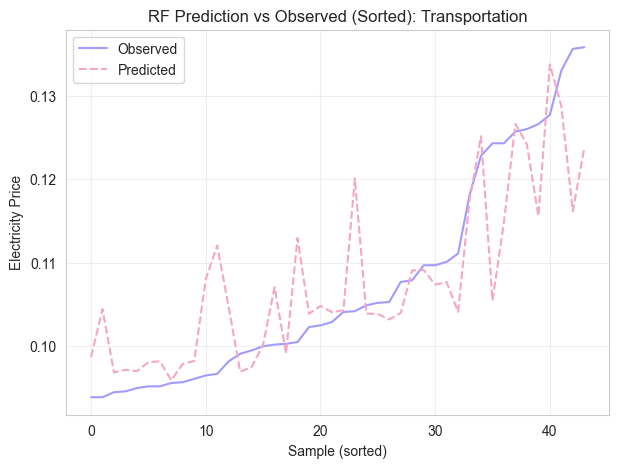

In [19]:
# ranking
sorted_idx = np.argsort(y_test.values)

plt.figure(figsize=(7,5))

plt.plot(
    y_test.values[sorted_idx],
    label='Observed',
    color=info['color']
)

plt.plot(
    y_test_pred[sorted_idx],
    label='Predicted',
    color='#F4A7C5',
    linestyle='--'
)

plt.xlabel('Sample (sorted)')
plt.ylabel('Electricity Price')
plt.title(f'RF Prediction vs Observed (Sorted): {info["label"]}')

plt.legend()
plt.grid(alpha=0.3)
plt.show()

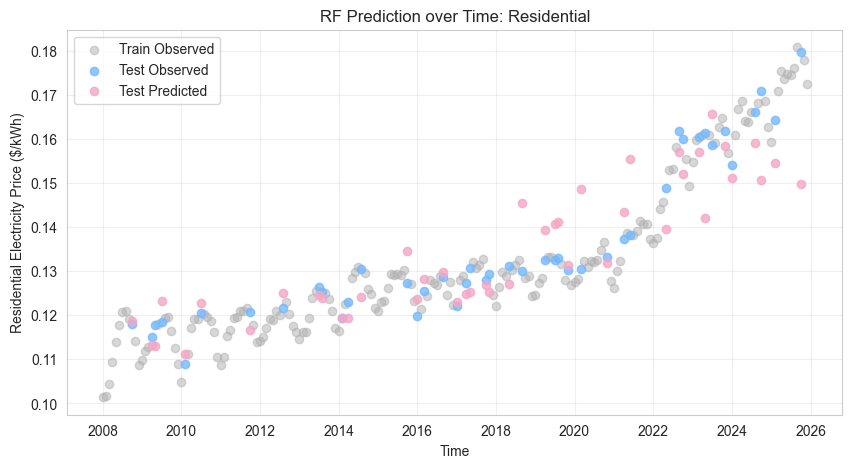

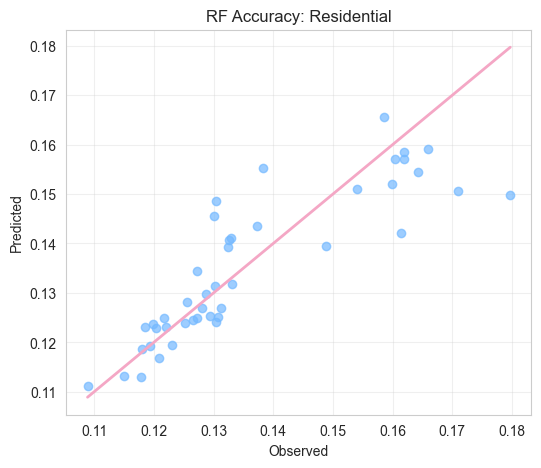

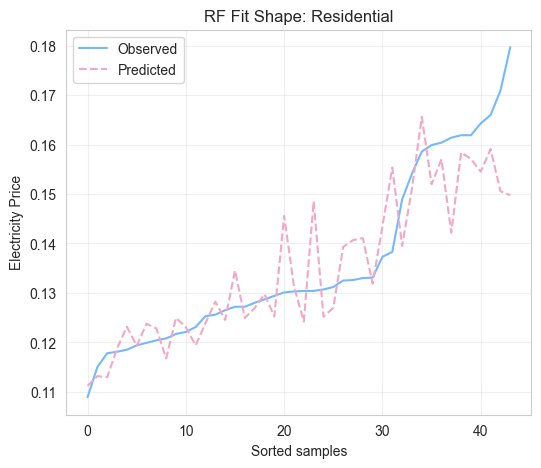

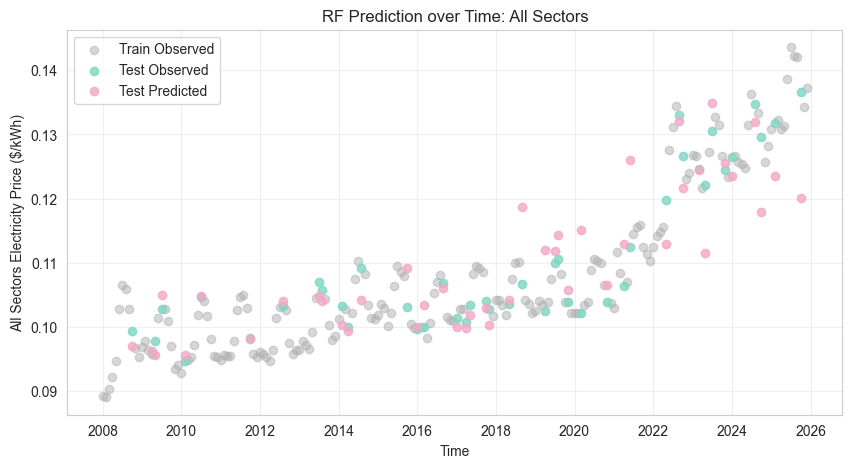

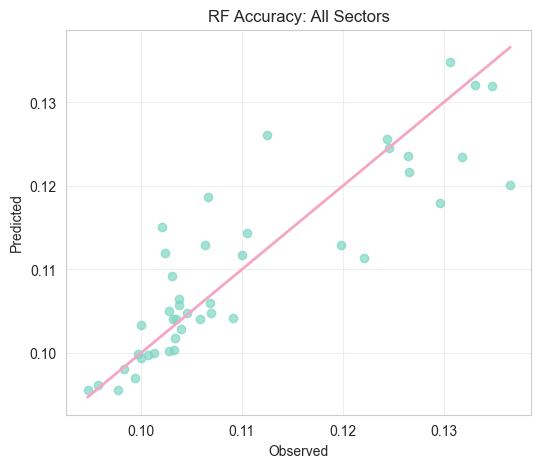

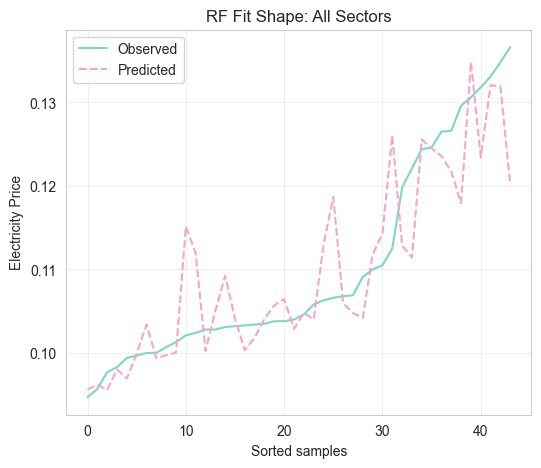

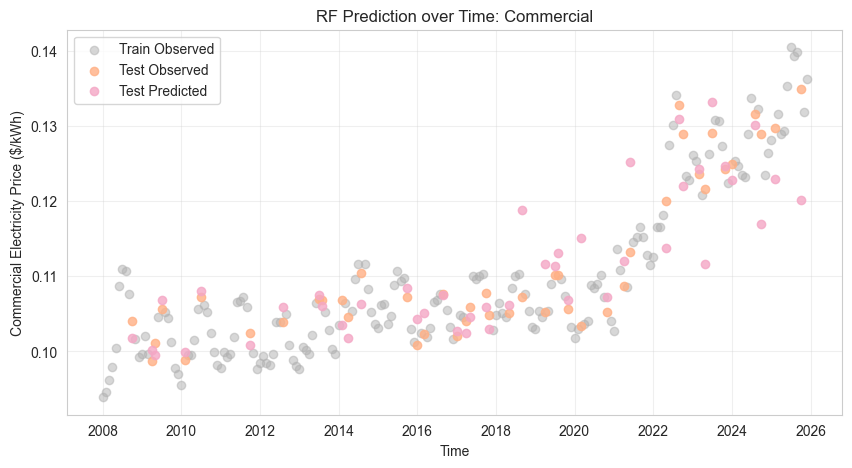

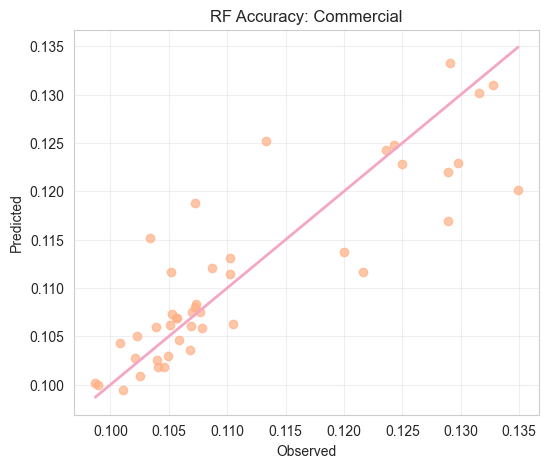

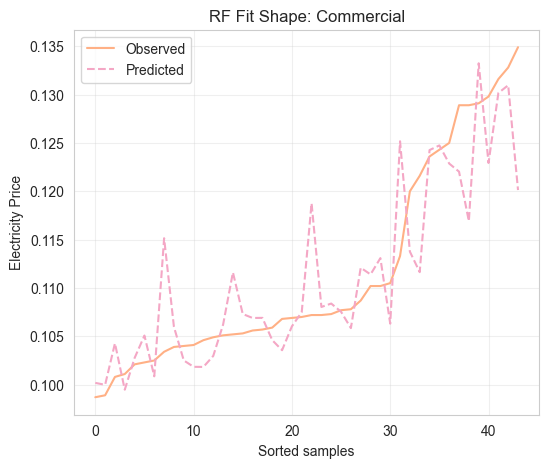

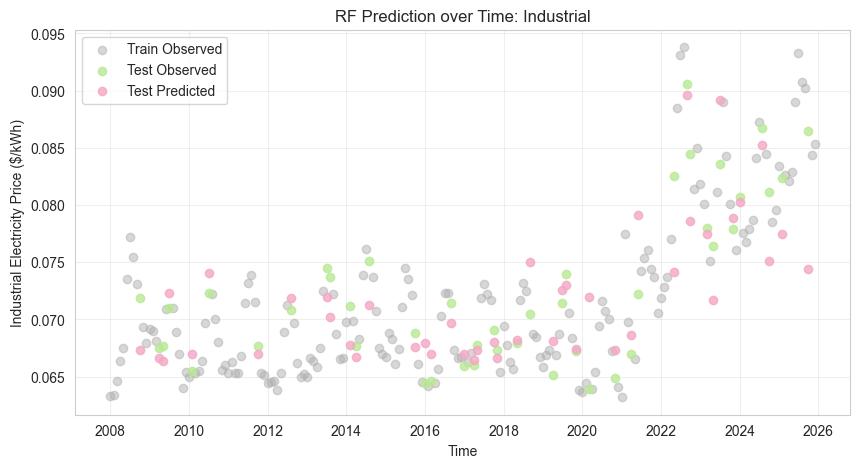

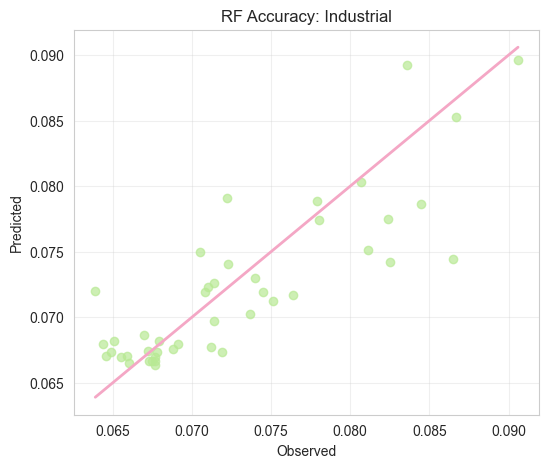

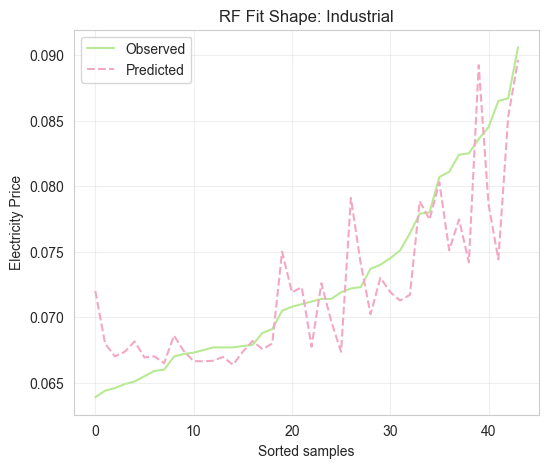

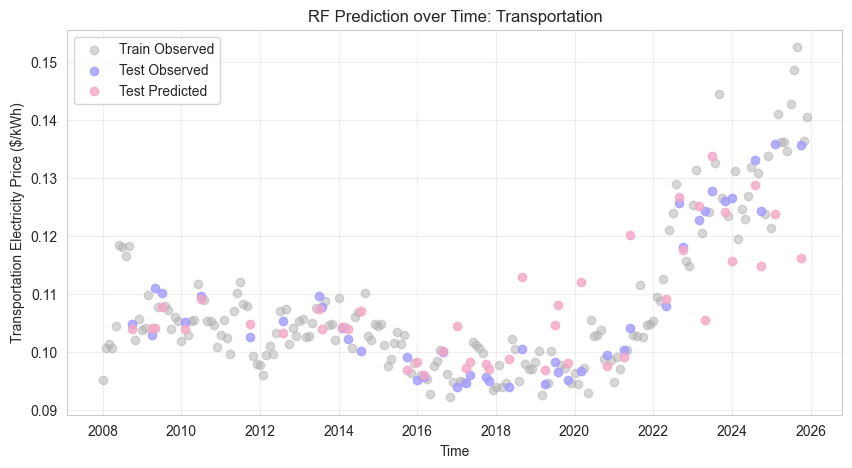

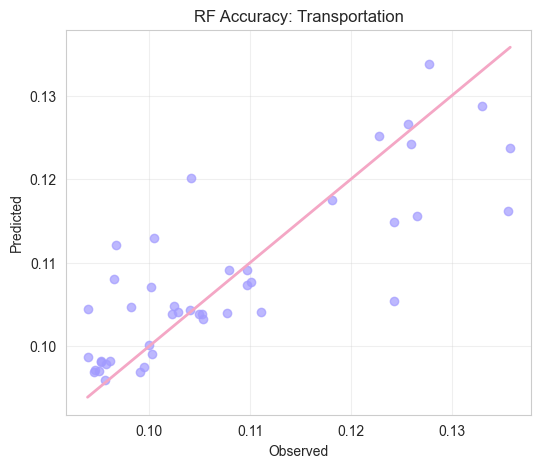

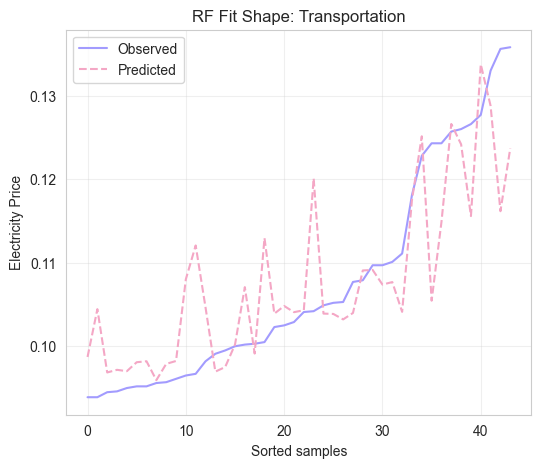

In [20]:
for sector, info in sector_info.items():

    # Build dataset
    df = pd.DataFrame({
        'gas_price': ff_price_T['natural gas'],
        'ng_share': net_gene_T['ng_share'],
        'gas_receipt': ff_receipt_T['natural gas'],
        'ele_price': ele_price_T[sector]
    }).dropna()

    # using time for plotting
    df.index = pd.to_datetime(df.index, errors='coerce')
    df = df.sort_index()

    X = df[['gas_price', 'ng_share', 'gas_receipt']]
    y = df['ele_price']

    # Random split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    # Model
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Plot 1：Time scatter
    plt.figure(figsize=(10,5))

    # train
    plt.scatter(
        y_train.index,
        y_train,
        color='#B0B0B0',
        alpha=0.5,
        label='Train Observed'
    )

    # test
    plt.scatter(
        y_test.index,
        y_test,
        color=info['color'],
        alpha=0.8,
        label='Test Observed'
    )

    # test
    plt.scatter(
        y_test.index,
        y_test_pred,
        color='#F4A7C5',
        alpha=0.8,
        label='Test Predicted'
    )

    plt.xlabel('Time')
    plt.ylabel(f'{info["label"]} Electricity Price ($/kWh)')
    plt.title(f'RF Prediction over Time: {info["label"]}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Plot 2：Scatter
    plt.figure(figsize=(6,5))

    plt.scatter(
        y_test,
        y_test_pred,
        color=info['color'],
        alpha=0.7
    )

    min_val = min(y_test.min(), y_test_pred.min())
    max_val = max(y_test.max(), y_test_pred.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        color='#F4A7C5',
        linewidth=2
    )

    plt.xlabel('Observed')
    plt.ylabel('Predicted')
    plt.title(f'RF Accuracy: {info["label"]}')
    plt.grid(alpha=0.3)
    plt.show()

    # Plot 3：Sorted comparison
    sorted_idx = np.argsort(y_test.values)

    plt.figure(figsize=(6,5))

    plt.plot(
        y_test.values[sorted_idx],
        label='Observed',
        color=info['color']
    )

    plt.plot(
        y_test_pred[sorted_idx],
        label='Predicted',
        color='#F4A7C5',
        linestyle='--'
    )

    plt.xlabel('Sorted samples')
    plt.ylabel('Electricity Price')
    plt.title(f'RF Fit Shape: {info["label"]}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()